In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression

import warnings 
warnings.filterwarnings('ignore')

In [3]:
X, y = make_regression(n_samples = 100, n_features = 1, n_informative = 1, n_targets = 1, noise = 20, random_state = 13)
X.shape, y.shape

((100, 1), (100,))

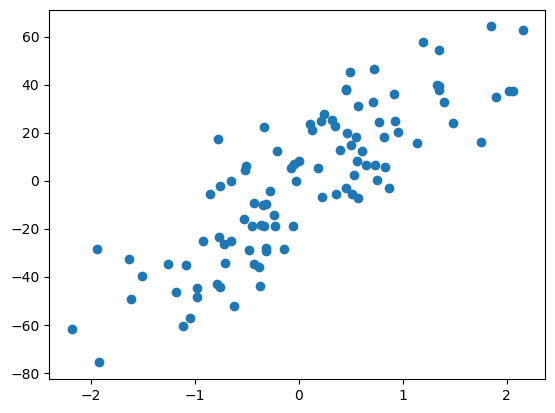

In [4]:
plt.scatter(X,y)

In [6]:
# First apply Linear Regression
from sklearn.linear_model import LinearRegression
lr_reg = LinearRegression()
lr_reg.fit(X,y)

LinearRegression()

In [7]:
lr_reg.intercept_

np.float64(-2.29474455867698)

In [8]:
lr_reg.coef_

array([27.82809103])

In [33]:
# Now apply Ridge Regresson
ridge_reg = Ridge(alpha = 0)
ridge_reg.fit(X, y)

alpha_0 = ridge_reg.predict(X)

In [38]:
print(ridge_reg.intercept_)
print(ridge_reg.coef_)

-1.4248441496033308
[12.93442104]


In [39]:
ridge_reg = Ridge(alpha = 10)
ridge_reg.fit(X, y)

alpha_10 = ridge_reg.predict(X)

print(ridge_reg.intercept_)
print(ridge_reg.coef_)

-2.1269130035235726
[24.9546267]


In [40]:
ridge_reg = Ridge(alpha = 100)
ridge_reg.fit(X, y)

alpha_100 = ridge_reg.predict(X)

print(ridge_reg.intercept_)
print(ridge_reg.coef_)

-1.4248441496033308
[12.93442104]


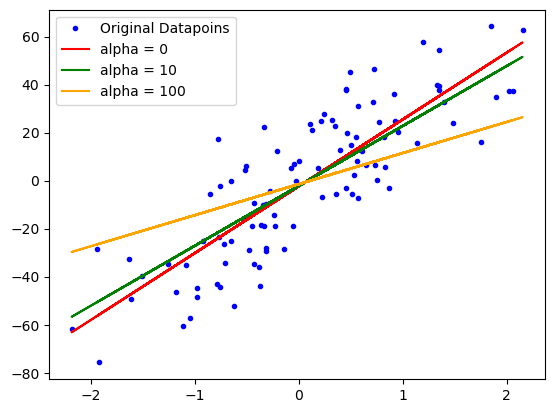

In [41]:
plt.plot(X,y, 'b.', label = 'Original Datapoins')
plt.plot(X, alpha_0, color = 'red', label = 'alpha = 0')
plt.plot(X, alpha_10, color = 'green', label = 'alpha = 10')
plt.plot(X, alpha_100, color = 'orange', label = 'alpha = 100')
plt.legend()

# Ridge Regression From Scracth

In [51]:
class ManualRidge:
    def __init__(self, alpha = 0.1):
        self.intercept_ = None
        self.coef_ = None
        self.alpha = alpha

    def fit(self, X_train, y_train):
        numerator = 0 
        denominator = 0

        for i in range(X_train.shape[0]):
            numerator = numerator + (y_train.mean() - y_train[i]) * (X_train.mean() - X_train[i])
            denominator = denominator + (X_train.mean() - X_train[i])**2 

        self.coef_ = numerator/(denominator + self.alpha)
        self.intercept_ = y_train.mean() - (self.coef_*X_train.mean())

        print(self.intercept_)
        print(self.coef_)

    def predict(self, X_test):
        pass

In [59]:
ridge_reg = ManualRidge(alpha = 100)

In [60]:
ridge_reg.fit(X, y)

[-1.42484415]
[12.93442104]
